In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MCP neuron for AND

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements AND operation using MCP neuron.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result_and = MCP_Neurons_AND(X1, X2, T)
print("AND output:", result_and)

AND output: [0, 0, 0, 1]


MCP neuron for OR

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print("OR output:", result_or)

OR output: [0, 1, 1, 1]


Question 1: Limitations of MCP Neurons

*   MCP neurons do not learn from data.
*   They use fixed threshold values.
*   They are very simple and only handle basic binary logic.
*   They cannot solve non-linearly separable problems such as XOR.
*   They are not a realistic full model of biological neurons.

Question 2: Can MCP solve XOR?

A single MCP neuron cannot solve XOR because XOR is not linearly separable. However, XOR can be built using multiple neurons combined together.

Load the MNIST 0 vs 1 dataset

In [ ]:
# Load dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/mnist_0_and_1.csv")

# Features and labels
X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Visualize some 0s and 1s

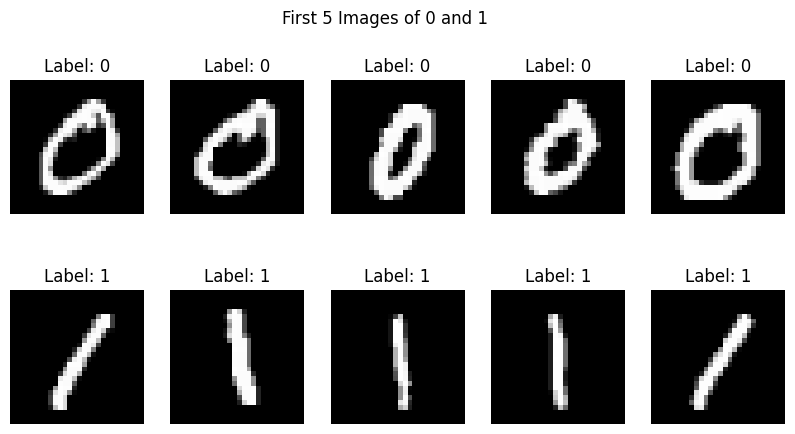

In [ ]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1")
    plt.show()

Initialize weights and bias

In [ ]:
weights = np.zeros(X.shape[1])   # 784 weights
bias = 0
learning_rate = 0.1
epochs = 100

print("Weights shape:", weights.shape)
print("Initial bias:", bias)

Weights shape: (784,)
Initial bias: 0


Decision function

In [ ]:
def decision_function(X, weights, bias):
    """
    Predict labels using step function.
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

Perceptron training function

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train perceptron using perceptron learning algorithm.
    """
    for epoch in range(epochs):
        errors = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred != y[i]:
                update = learning_rate * (y[i] - y_pred)
                weights = weights + update * X[i]
                bias = bias + update
                errors += 1

        print(f"Epoch {epoch+1}/{epochs}, Errors: {errors}")

        if errors == 0:
            print("Training converged early.")
            break

    final_predictions = decision_function(X, weights, bias)
    accuracy = np.mean(final_predictions == y)

    return weights, bias, accuracy

Train the perceptron

In [ ]:
weights, bias, accuracy = train_perceptron(
    X, y, weights, bias, learning_rate=0.1, epochs=100
)

print("Final Accuracy:", accuracy)

Epoch 1/100, Errors: 42
Epoch 2/100, Errors: 23
Epoch 3/100, Errors: 17
Epoch 4/100, Errors: 17
Epoch 5/100, Errors: 13
Epoch 6/100, Errors: 9
Epoch 7/100, Errors: 3
Epoch 8/100, Errors: 6
Epoch 9/100, Errors: 14
Epoch 10/100, Errors: 10
Epoch 11/100, Errors: 6
Epoch 12/100, Errors: 3
Epoch 13/100, Errors: 0
Training converged early.
Final Accuracy: 1.0


Show misclassified images

In [ ]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Question 1: What does the shape of X represent?

The shape of X represents the number of samples and the number of features. Each row is one image and each column is one pixel value.

Question 2: What does the shape of y represent?

The shape of y represents the number of labels, one for each image.

Question 3: What does the weights array represent?

The weights array represents the importance of each input pixel in making the classification.

Question 4: Why initialize weights to zero?

Weights are initialized to zero to start from a neutral state with no prior preference. The model then learns from the data.

Question 5: What is the purpose of output = np.dot(X[i], weights) + bias?

It computes the weighted sum of the input features plus bias, which is used to decide the predicted class.

Question 6: What happens when the prediction is wrong?

When prediction is wrong, the weights and bias are updated using the perceptron learning rule so the model moves toward correct classification.

Question 7: Why is final accuracy important?

Final accuracy tells how well the perceptron classified the dataset. For 0 vs 1, the accuracy is usually very high because those digits are easier to separate.

Question 8: What does misclassified_idx store?

It stores the indices of images where predicted labels do not match true labels.

Question 9: What does “All images were correctly classified!” mean?

It means the model predicted every image correctly on that dataset, giving 100% accuracy.

Task 3

In [ ]:
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/mnist_3_and_5.csv")

X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


In [ ]:
y_35_binary = np.where(y_35 == 5, 1, 0)

Initialize again

In [ ]:
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0

Train

In [ ]:
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary, weights_35, bias_35, learning_rate=0.1, epochs=100
)

print("Final Accuracy for 3 vs 5:", accuracy_35)

Epoch 1/100, Errors: 231
Epoch 2/100, Errors: 172
Epoch 3/100, Errors: 160
Epoch 4/100, Errors: 144
Epoch 5/100, Errors: 140
Epoch 6/100, Errors: 136
Epoch 7/100, Errors: 110
Epoch 8/100, Errors: 121
Epoch 9/100, Errors: 126
Epoch 10/100, Errors: 119
Epoch 11/100, Errors: 110
Epoch 12/100, Errors: 115
Epoch 13/100, Errors: 94
Epoch 14/100, Errors: 109
Epoch 15/100, Errors: 100
Epoch 16/100, Errors: 94
Epoch 17/100, Errors: 108
Epoch 18/100, Errors: 103
Epoch 19/100, Errors: 107
Epoch 20/100, Errors: 93
Epoch 21/100, Errors: 82
Epoch 22/100, Errors: 85
Epoch 23/100, Errors: 74
Epoch 24/100, Errors: 87
Epoch 25/100, Errors: 96
Epoch 26/100, Errors: 78
Epoch 27/100, Errors: 73
Epoch 28/100, Errors: 84
Epoch 29/100, Errors: 78
Epoch 30/100, Errors: 75
Epoch 31/100, Errors: 91
Epoch 32/100, Errors: 78
Epoch 33/100, Errors: 84
Epoch 34/100, Errors: 71
Epoch 35/100, Errors: 71
Epoch 36/100, Errors: 86
Epoch 37/100, Errors: 73
Epoch 38/100, Errors: 81
Epoch 39/100, Errors: 61
Epoch 40/100, Err

Show misclassified images

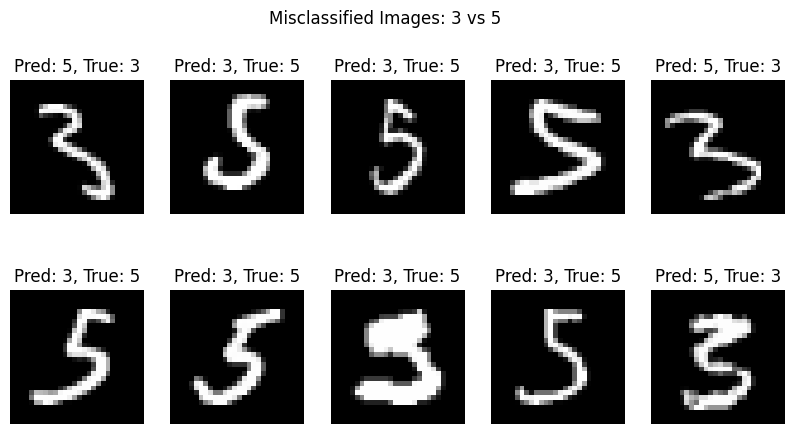

In [ ]:
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]

if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        pred_label = 5 if y_pred_35[idx] == 1 else 3
        true_label = 5 if y_35_binary[idx] == 1 else 3
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")

    plt.suptitle("Misclassified Images: 3 vs 5")
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion for task 3

For 3 vs 5 classification, the perceptron usually performs worse than 0 vs 1 because digits 3 and 5 look more similar. This causes more misclassification. Since perceptron is a linear classifier, it struggles more when classes are harder to separate.